In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load dataset
df = pd.read_csv('diabetes.csv')  

# Basic stats
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df['Outcome'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

In [5]:
# Preprocessing
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)    
# Store model results
model_results = []

In [6]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, LR.predict_proba(X_test)[:, 1])
model_results.append(('Logistic Regression', acc, roc_auc)) 

print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Confusion Matrix:
 [[79 20]
 [18 37]]


In [7]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)
y_pred = DT.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, DT.predict_proba(X_test)[:, 1])
model_results.append(('Decision Tree', acc, roc_auc))

print("Decision Tree")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        99
           1       0.62      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154

Confusion Matrix:
 [[76 23]
 [18 37]]


In [8]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, KNN.predict_proba(X_test)[:, 1])
model_results.append(('KNN', acc, roc_auc))

print("KNN")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


KNN
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        99
           1       0.57      0.49      0.53        55

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.68       154

Confusion Matrix:
 [[79 20]
 [28 27]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier()
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, RF.predict_proba(X_test)[:, 1])
model_results.append(('Random Forest', acc, roc_auc))

print("Random Forest Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest Classifier
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        99
           1       0.62      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:
 [[78 21]
 [21 34]]


In [10]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, svc.predict_proba(X_test)[:, 1])
model_results.append(('SVM', acc, roc_auc))

print("Support Vector Machine (SVC)")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Support Vector Machine (SVC)
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        99
           1       0.63      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154

Confusion Matrix:
 [[81 18]
 [24 31]]


In [11]:
from sklearn.naive_bayes import GaussianNB

GNB = GaussianNB()
GNB .fit(X_train, y_train)
y_pred = GNB .predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, GNB .predict_proba(X_test)[:, 1])
model_results.append(('Naive Bayes', acc, roc_auc))

print("Gaussian Naive Bayes")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Gaussian Naive Bayes
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

Confusion Matrix:
 [[79 20]
 [16 39]]


In [12]:
from sklearn.ensemble import AdaBoostClassifier

ABC = AdaBoostClassifier()
ABC.fit(X_train, y_train)
y_pred = ABC.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, ABC.predict_proba(X_test)[:, 1])
model_results.append(('AdaBoost', acc, roc_auc))

print("AdaBoost Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


AdaBoost Classifier
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        99
           1       0.68      0.73      0.70        55

    accuracy                           0.78       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.78      0.78       154

Confusion Matrix:
 [[80 19]
 [15 40]]


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier()
GBC.fit(X_train, y_train)
y_pred = GBC.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, GBC.predict_proba(X_test)[:, 1])
model_results.append(('Gradient Boosting', acc, roc_auc))

print("Gradient Boosting Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Gradient Boosting Classifier
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
 [[78 21]
 [18 37]]


In [14]:
from xgboost import XGBClassifier

XGB = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
XGB.fit(X_train, y_train)
y_pred = XGB.predict(X_test)

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, XGB.predict_proba(X_test)[:, 1])
model_results.append(('XGBoost', acc, roc_auc))

print("XGBoost Classifier")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


XGBoost Classifier
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154

Confusion Matrix:
 [[72 27]
 [16 39]]


Model Comparison:

                 Model  Accuracy   ROC-AUC
6             AdaBoost  0.779221  0.813131
5          Naive Bayes  0.766234  0.825344
0  Logistic Regression  0.753247  0.814692
7    Gradient Boosting  0.746753  0.808999
1        Decision Tree  0.733766  0.720202
3        Random Forest  0.727273  0.820753
4                  SVM  0.727273  0.804591
8              XGBoost  0.720779  0.776125
2                  KNN  0.688312  0.764279


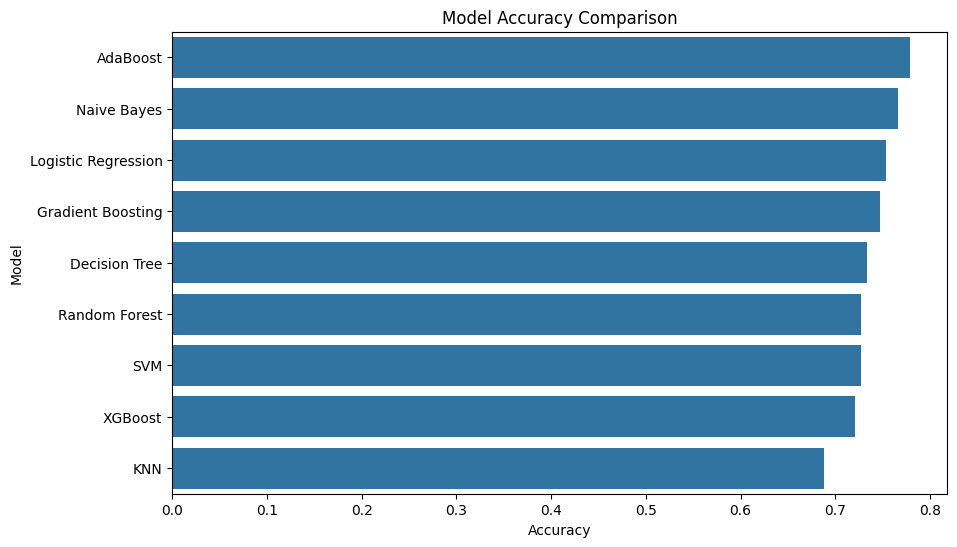

In [15]:
results_df = pd.DataFrame(model_results, columns=['Model', 'Accuracy', 'ROC-AUC'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print("Model Comparison:\n")
print(results_df)

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()
